In [1]:
from aggregation.subject_utils import get_subject_image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
extracted_data = pd.read_csv('FreehandLine/polygon_extractor_extractions.csv')

In [3]:
extracted_data

,classification_id,user_name,user_id,workflow_id,task,created_at,subject_id,extractor,data.aggregation_version,data.frame0.T0_tool0_pathX,data.frame0.T0_tool0_pathY,data.frame0.gold_standard
0,710296763,ramanakumars,2245813,31207,T0,2026-03-02 17:20:54 UTC,117466399,polygon_extractor,5.3.0,"[[220.1, 220.8, 221.5, 222.2, 222.2, 223, 223....","[[428.8, 428.8, 428.8, 428.1, 427.4, 426.6, 42...",False
1,710296894,ramanakumars,2245813,31207,T0,2026-03-02 17:21:21 UTC,117466478,polygon_extractor,5.3.0,"[[350.8, 351.4, 352.5, 353.1, 353.7, 354.3, 35...","[[181.2, 181.2, 181.7, 182.3, 182.9, 183.5, 18...",False
2,710297028,ramanakumars,2245813,31207,T0,2026-03-02 17:21:45 UTC,117466599,polygon_extractor,5.3.0,"[[272.8, 273.8, 274.8, 275.8, 276.8, 277.8, 27...","[[383.5, 383.5, 383.5, 383.5, 383.5, 383.5, 38...",False
3,710297079,ramanakumars,2245813,31207,T0,2026-03-02 17:21:53 UTC,117477797,polygon_extractor,5.3.0,"[[179.3, 180.3, 181.3, 181.3, 182.3, 182.3, 18...","[[105.5, 105.5, 107.5, 108.5, 108.5, 109.5, 11...",False
4,710297195,ramanakumars,2245813,31207,T0,2026-03-02 17:22:10 UTC,117466433,polygon_extractor,5.3.0,"[[292.3, 294.3, 295.3, 297.3, 300.3, 303.3, 30...","[[242.5, 242.5, 242.5, 242.5, 243.5, 243.5, 24...",False
5,710297240,ramanakumars,2245813,31207,T0,2026-03-02 17:22:17 UTC,117477843,polygon_extractor,5.3.0,"[[335.3, 337.3, 340.3, 342.3, 344.3, 345.3, 34...","[[279.5, 279.5, 279.5, 279.5, 279.5, 279.5, 27...",False


Just like the point data, these extracted data are in the same format. However, since this is a freehand line, the data is stored as a list of (x, y) coordinates. Each row contains a list of lines, where each line is a list of points. They are stored as JSON strings.

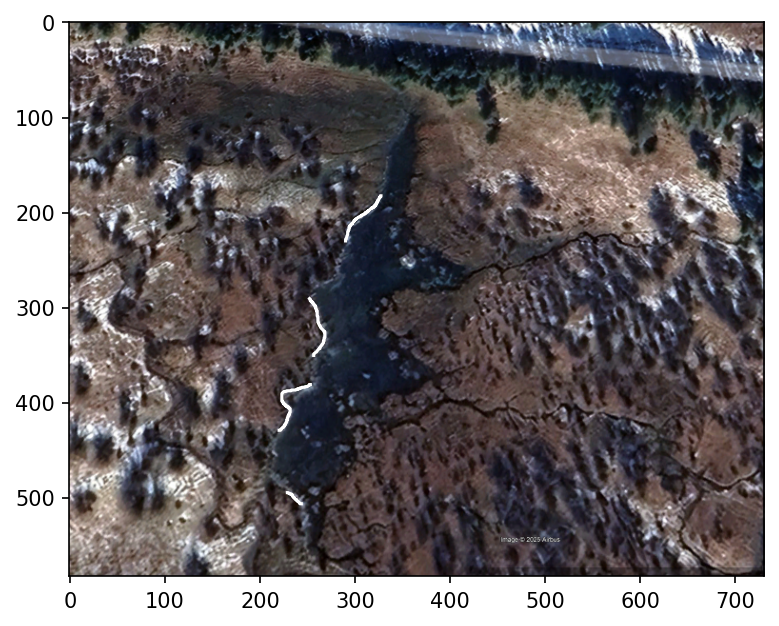

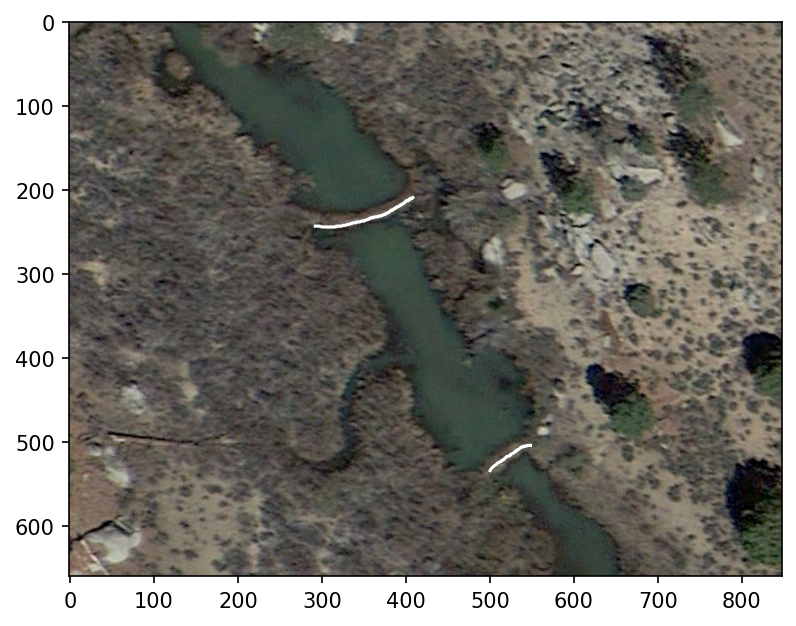

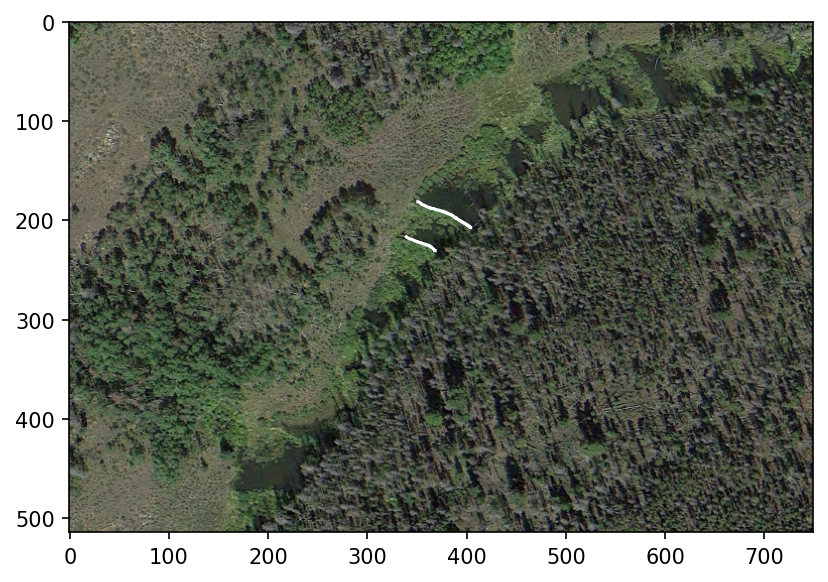

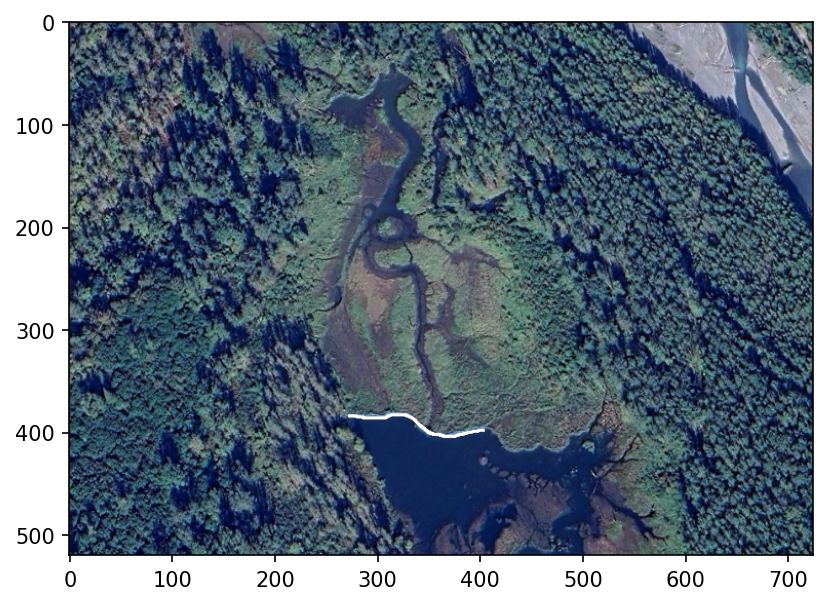

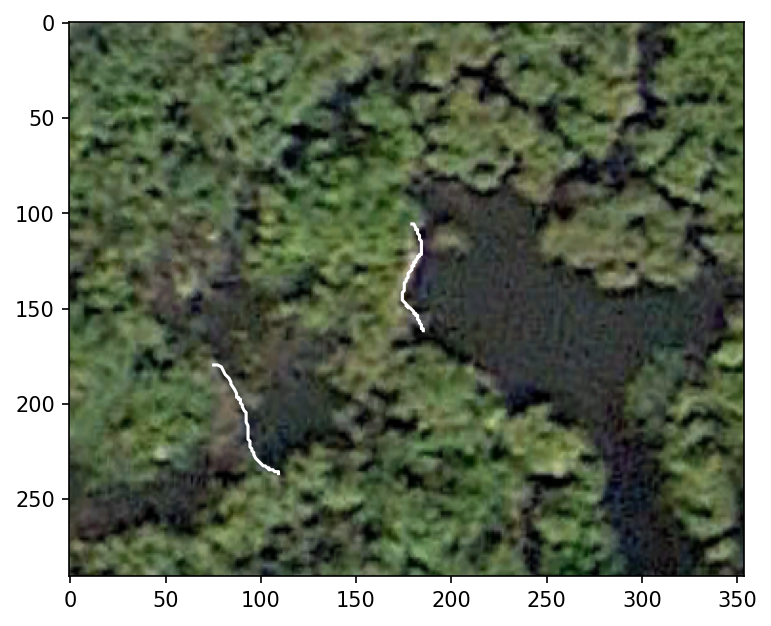

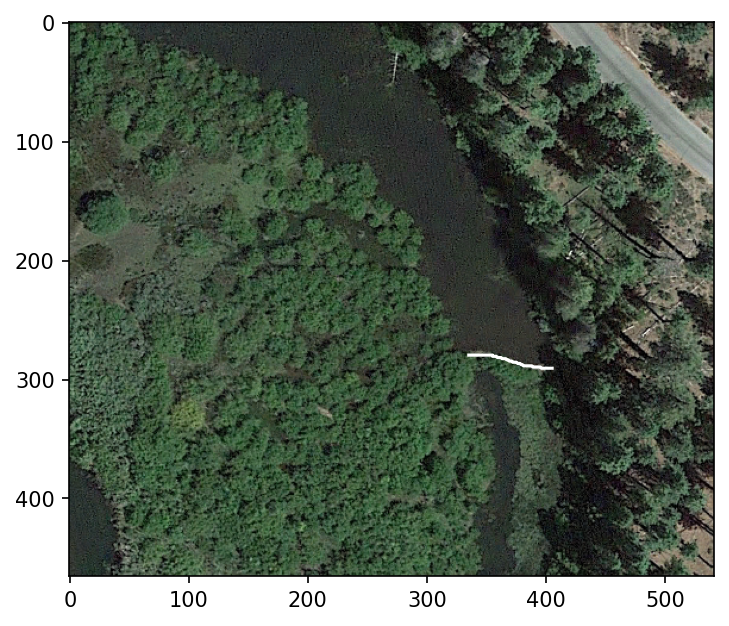

In [4]:
subject_ids = np.unique(extracted_data['subject_id'])

for subject_id in subject_ids:

    classifications = extracted_data[extracted_data['subject_id'] == subject_id]
    image = get_subject_image(subject_id)

    fig, ax = plt.subplots(1, 1, dpi=150)
    ax.imshow(image)

    for idx, classification in classifications.iterrows():
        # get the list of lines first 
        pathX = json.loads(classification['data.frame0.T0_tool0_pathX'])
        pathY = json.loads(classification['data.frame0.T0_tool0_pathY'])

        # then loop over each line (which is a collection of points)
        for xx, yy in zip(pathX, pathY):
            # and plot those points as a line
            ax.plot(xx, yy, '-', color='white')
    plt.show()